In [1]:
import pandas as pd
import numpy as np

In [2]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\vic\Downloads\student_dropout_dataset_5000.csv")

In [4]:
df.head()

,Age,Current Educational Level,Parent Educational Level,Socioeconomic status,Platform login frequency (weekly),Course interaction logs (Videos Watched),Course interaction logs (Quiz attempts),Course interaction logs (Discussion posts),Late submission rate,Assignment completion rate (weekly),...,Social interaction level,Confidence level,Resilience,Grit,Growth mindset,Test & quiz scores,Class grade (weekly),Homework accuracy,Access to stable internet/equipment,DROPOUT/INACTIVITY RATE/ TARGET
0,23,Higher National Diploma,Senior Secondary,Medium,NaN,up-to-date,NaN,no,medium,24.4,...,Moderate,High,Good,Developing,Strong,8.0,34.0,30.6,NaN,HIGH
1,19,National Diploma,Senior Secondary,High,NaN,NaN,1.0,no,low,58.3,...,High,Very High,Low,Low,Moderate,15.4,63.4,67.4,Medium,LOW
2,24,Undergraduate,Bachelors Degree,Low,17.153898,incomplete,NaN,yes,high,68.9,...,Very High,Moderate,Low,Good,Strong,16.0,53.6,78.1,High,MEDIUM
3,30,Upskilling,Senior Secondary,Medium,NaN,NaN,2.0,NaN,low,84.2,...,Moderate,High,Good,Good,Strong,15.1,87.6,74.3,High,LOW
4,18,National Diploma,Senior Secondary,Medium,NaN,NaN,3.0,no,NaN,42.0,...,Moderate,Low,High,Low,Low,5.2,73.6,33.6,High,LOW


In [5]:
df.shape

(5000, 28)

In [6]:
df.isna().sum()

Age                                              0
Current Educational Level                        0
Parent Educational Level                         0
Socioeconomic status                             0
Platform login frequency (weekly)             1739
Course interaction logs (Videos Watched)      1486
Course interaction logs (Quiz attempts)       1425
Course interaction logs (Discussion posts)    1973
Late submission rate                          2021
Assignment completion rate (weekly)              0
Class attendance (weekly)                        0
Study consistency                                0
Focus quality                                    0
Sleep habits                                     0
Self-regulation                                  0
Procrastination level                            0
Motivation type                                  0
Stress level                                     0
Social interaction level                         0
Confidence level               

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 28 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Age                                         5000 non-null   float64
 1   Current Educational Level                   5000 non-null   object 
 2   Parent Educational Level                    5000 non-null   object 
 3   Socioeconomic status                        5000 non-null   object 
 4   Platform login frequency (weekly)           5000 non-null   float64
 5   Course interaction logs (Videos Watched)    5000 non-null   object 
 6   Course interaction logs (Quiz attempts)     5000 non-null   float64
 7   Course interaction logs (Discussion posts)  5000 non-null   object 
 8   Late submission rate                        5000 non-null   object 
 9   Assignment completion rate (weekly)         5000 non-null   float64
 10  Class attend

In [8]:
categorical_cols = [
    'Current Educational Level', 'Parent Educational Level', 'Socioeconomic status',
    'Course interaction logs (Videos Watched)', 'Course interaction logs (Discussion posts)',
    'Late submission rate', 'Study consistency', 'Focus quality', 'Sleep habits',
    'Self-regulation', 'Procrastination level', 'Motivation type','Stress level', 'Social interaction level', 
    'Confidence level','Resilience', 'Grit', 'Growth mindset', 'Access to stable internet/equipment'                           
]

numerical_cols = [
    'Age', 'Platform login frequency (weekly)', 'Course interaction logs (Quiz attempts)',
    'Assignment completion rate (weekly)', 'Class attendance (weekly)', 'Test & quiz scores', 'Class grade (weekly)', 'Homework accuracy'
]

target_col = 'DROPOUT/INACTIVITY RATE/ TARGET'

In [9]:
# Map textual categories to numeric values
mapping = {"LOW": 0.2, "MEDIUM": 0.5, "HIGH": 0.8}

def convert_target(val):
    try:
        # Try to convert directly to float (handles "0.9", "0.7", etc.)
        return float(val)
    except:
        # If it's text, map it
        return mapping.get(str(val).upper(), np.nan)

df[target_col] = df[target_col].apply(convert_target)

In [10]:
# Fill only categorical NaNs with "Optional"
df[categorical_cols] = df[categorical_cols].fillna("Optional")

# Fill numeric NaNs with 0 (or the column mean if you prefer)
df[numerical_cols] = df[numerical_cols].apply(
    lambda x: x.fillna(x.mean()) if x.dtype != "O" else x
)

In [11]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import Dense, LayerNormalization, Dropout

# 1. Tokenization (each categorical column as a token string)
categorical_texts = df[categorical_cols].astype(str).agg(" ".join, axis=1)

# 2. Tokenize entire sequence of categorical data
text_vectorizer = layers.TextVectorization(
    output_mode="int", output_sequence_length=len(categorical_cols)
)
text_vectorizer.adapt(categorical_texts)
vocab_size = len(text_vectorizer.get_vocabulary())

# 3. Numerical normalization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Split
from sklearn.model_selection import train_test_split
X_train_text, X_test_text, X_train_num, X_test_num, y_train, y_test = train_test_split(
    categorical_texts, df[numerical_cols], df[target_col].astype(float), test_size=0.2, random_state=42
)

In [12]:
# Transformer Encoder block
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    x = layers.Dropout(dropout)(x)
    res = x + inputs

    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = layers.Dense(ff_dim, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(inputs.shape[-1])(x)  # project back to original embedding size
    return x + res

# Text input (categorical sequence)
text_input = layers.Input(shape=(None,), dtype=tf.int32, name="categorical_sequence")
x = layers.Embedding(input_dim=vocab_size, output_dim=64)(text_input)

# Add a few transformer blocks
for _ in range(2):
    x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.2)

x = layers.GlobalAveragePooling1D()(x)

# Numerical input
num_input = layers.Input(shape=(len(numerical_cols),), name="numerical_input")

# Combine both
combined = layers.Concatenate()([x, num_input])
combined = Dense(128, activation="relu")(combined)
combined = Dropout(0.3)(combined)
combined = Dense(64, activation="relu")(combined)
output = Dense(1, activation="linear")(combined)

model = Model(inputs=[text_input, num_input], outputs=output)
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ categorical_sequen… │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 64)  │      3,264 │ categorical_sequ… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, None, 64)  │        128 │ embedding[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, None, 64)  │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, None, 64)  │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, None, 64)  │          0 │ dropout_1[0][0],  │
│                     │                   │            │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, None, 64)  │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, None, 128) │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, None, 128) │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, None, 64)  │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, None, 64)  │          0 │ dense_1[0][0],    │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, None, 64)  │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, None, 64)  │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, None, 64)  │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, None, 64)  │          0 │ dropout_4[0][0],  │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, None, 64)  │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, None, 128) │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, None, 128) │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, None, 64)  │      8,256 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 187,329 (731.75 KB)

 Trainable params: 187,329 (731.75 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
X_train_seq = text_vectorizer(X_train_text)
X_test_seq = text_vectorizer(X_test_text)

history = model.fit(
    {"categorical_sequence": X_train_seq, "numerical_input": X_train_num},
    y_train,
    validation_data=({"categorical_sequence": X_test_seq, "numerical_input": X_test_num}, y_test),
    epochs=50,
    batch_size=64,
    verbose=1
)

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 27s 161ms/step - loss: 0.1024 - mae: 0.2477 - val_loss: 0.0492 - val_mae: 0.1900
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 110ms/step - loss: 0.0552 - mae: 0.1935 - val_loss: 0.0378 - val_mae: 0.1573
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - loss: 0.0435 - mae: 0.1702 - val_loss: 0.0374 - val_mae: 0.1561
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 106ms/step - loss: 0.0426 - mae: 0.1679 - val_loss: 0.0362 - val_mae: 0.1501
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - loss: 0.0400 - mae: 0.1623 - val_loss: 0.0528 - val_mae: 0.1654
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step - loss: 0.0398 - mae: 0.1615 - val_loss: 0.0355 - val_mae: 0.1526
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - loss: 0.0389 - mae: 0.1594 - val_loss: 0.0389 - val_mae: 0.1501
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - loss: 0.0392 - mae: 0.1602 - val_loss: 0.0363 - val_mae: 0.1609
Epoch 9/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - lo

In [14]:
# Predict dropout values
y_pred_continuous = model.predict({
    "categorical_sequence": X_test_seq,
    "numerical_input": X_test_num
}).flatten()

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step


In [15]:
# Define bins for categorization
def categorize_dropout(value):
    if value < 0.33:
        return "LOW"
    elif value < 0.66:
        return "MEDIUM"
    else:
        return "HIGH"

# Apply to predictions and true values
y_pred_labels = np.array([categorize_dropout(v) for v in y_pred_continuous])
y_true_labels = np.array([categorize_dropout(v) for v in y_test])

In [16]:
print("Classification Report:\n")
print(classification_report(y_true_labels, y_pred_labels, target_names=["LOW", "MEDIUM", "HIGH"]))

Classification Report:

              precision    recall  f1-score   support

         LOW       0.67      0.01      0.02       176
      MEDIUM       0.73      0.62      0.67       538
        HIGH       0.35      0.66      0.46       286

    accuracy                           0.53      1000
   macro avg       0.58      0.43      0.38      1000
weighted avg       0.61      0.53      0.50      1000



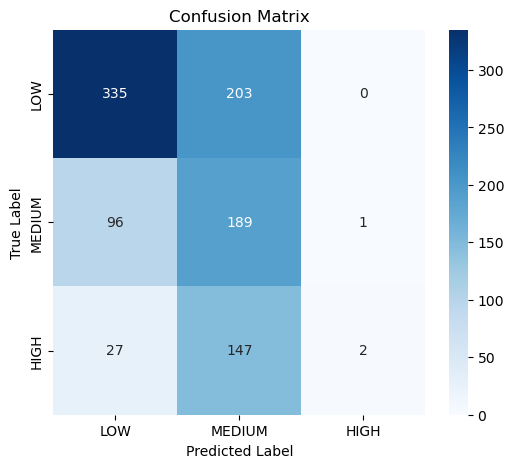

In [17]:
# Compute confusion matrix
cm = confusion_matrix(y_true_labels, y_pred_labels, labels=["LOW", "MEDIUM", "HIGH"])

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["LOW", "MEDIUM", "HIGH"],
            yticklabels=["LOW", "MEDIUM", "HIGH"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

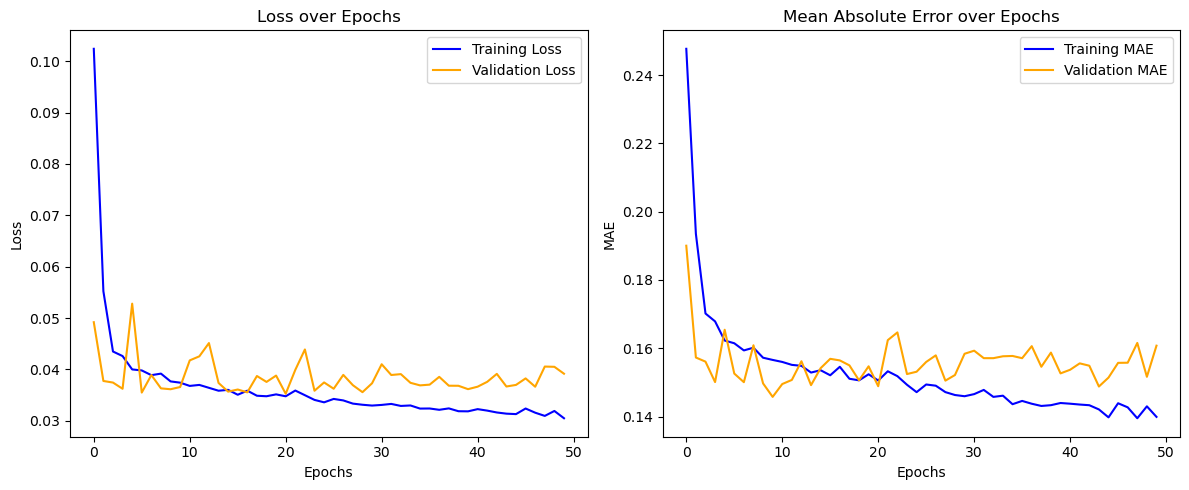

In [18]:
history_dict = history.history

plt.figure(figsize=(12, 5))

# --- LOSS ---
plt.subplot(1, 2, 1)
plt.plot(history_dict['loss'], label='Training Loss', color='blue')
plt.plot(history_dict['val_loss'], label='Validation Loss', color='orange')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# --- MAE ---
plt.subplot(1, 2, 2)
plt.plot(history_dict['mae'], label='Training MAE', color='blue')
plt.plot(history_dict['val_mae'], label='Validation MAE', color='orange')
plt.title('Mean Absolute Error over Epochs')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

In [19]:
test_loss, test_mae = model.evaluate(
    {"categorical_sequence": X_test_seq, "numerical_input": X_test_num},
    y_test,
    verbose=0
)

print(f"Test Loss (MSE): {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")

Test Loss (MSE): 0.0392
Test MAE: 0.1608


In [20]:
import numpy as np
import pandas as pd
import tensorflow as tf

# --- Default preprocessing references ---
default_cat_fill = "Optional"
default_num_fill = {col: df[col].mean() for col in numerical_cols}

def preprocess_single_student(student_data):
    """
    Prepares a single student's data for model prediction.
    Handles missing categorical/numerical fields gracefully.
    """
    # 1️⃣ Create a full feature dictionary with defaults
    student_filled = {}

    # Fill categorical fields
    for col in categorical_cols:
        student_filled[col] = str(student_data.get(col, default_cat_fill))

    # Fill numerical fields
    for col in numerical_cols:
        value = student_data.get(col, default_num_fill[col])
        # Handle missing or non-numeric
        try:
            student_filled[col] = float(value)
        except:
            student_filled[col] = default_num_fill[col]

    # 2️⃣ Convert to DataFrame for consistency
    student_df = pd.DataFrame([student_filled])

    # 3️⃣ Preprocess categorical and numeric inputs
    cat_text = student_df[categorical_cols].astype(str).agg(" ".join, axis=1)
    cat_seq = text_vectorizer(cat_text)
    num_scaled = scaler.transform(student_df[numerical_cols])

    return {"categorical_sequence": cat_seq, "numerical_input": num_scaled}

# --- Categorization helper ---
def categorize_dropout(value):
    if value < 0.33:
        return "LOW"
    elif value < 0.66:
        return "MEDIUM"
    else:
        return "HIGH"

# --- Prediction function ---
def predict_dropout(student_data):
    """
    Predicts dropout category for a given student's partial data.
    Automatically handles missing fields.
    """
    inputs = preprocess_single_student(student_data)
    pred_value = model.predict(inputs).flatten()[0]
    category = categorize_dropout(pred_value)

    print(f"Predicted dropout score: {pred_value:.3f} → Category: {category}")
    return category

In [21]:
# Example 1: Complete student info
student_1 = {
    "Age": 19,
    "Current Educational Level": "Undergraduate",
    "Parent Educational Level": "College",
    "Socioeconomic status": "Middle",
    "Platform login frequency (weekly)": 3,
    "Assignment completion rate (weekly)": 0.8,
    "Class attendance (weekly)": 0.9,
    "Test & quiz scores": 85,
    "Class grade (weekly)": 82,
    "Homework accuracy": 0.75,
    "Stress level": "Moderate",
    "Motivation type": "Intrinsic",
    "Access to stable internet/equipment": "Yes"
}

predict_dropout(student_1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
Predicted dropout score: 1.563 → Category: HIGH


'HIGH'

In [22]:
# Save the full model (architecture + weights + optimizer state)
model.save("student_dropout_model.keras")

In [23]:
import json

preprocessing_info = {
    "categorical_cols": categorical_cols,
    "numerical_cols": numerical_cols,
    "categorical_default": "Unknown",
    "numerical_default": 0.0
}

with open("inactivity_preprocessing_info.json", "w") as f:
    json.dump(preprocessing_info, f)

In [24]:
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import TextVectorization

# Wrap it
text_input = Input(shape=(1,), dtype=tf.string)
x = text_vectorizer(text_input)
vectorizer_model = Model(text_input, x)

# Save the wrapper model
vectorizer_model.save("inactivity_text_vectorizer_model.keras")

In [26]:
import joblib

joblib.dump(scaler, "inactivity_numerical_scaler.pkl")

['inactivity_numerical_scaler.pkl']